# Notebook 3 - Konversi ke TensorFlow Lite & Kuantisasi (Edge AI)
---
Adaptasi `anomaly_detection_tflite_conversion.ipynb`. Model **Autoencoder Dense** `.h5` dari Notebook 2 (dilatih pada dataset bersih hasil Notebook 1, 8 fitur) dikonversi ke beberapa varian TFLite:

| Varian | Ukuran bobot | Keterangan |
|---|---|---|
| `float32` | 32-bit | konversi dasar, tanpa kuantisasi |
| `dynamic` | 8-bit (bobot saja) | *dynamic range quantization*, aktivasi tetap float |
| `float16` | 16-bit | separuh ukuran, cocok untuk GPU/NPU |
| `int8` (full integer) | 8-bit bobot **dan** aktivasi, I/O int8 | paling kecil & cepat di MCU; butuh *representative dataset* |

Lalu: bandingkan **ukuran**, uji **inferensi** (`tf.lite.Interpreter`) terhadap model Keras asli, dan (opsional) tulis model int8 sebagai **header C** untuk ESP32/Arduino.

### 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Siapkan `c_writer.py` (opsional, untuk header C)
Modul kecil dari proyek referensi (utility membuat array C & header guard). Sel di bawah menuliskannya ke folder `notebooks/` di Drive,
jadi tidak perlu diunggah manual.

In [2]:
%%writefile /content/drive/MyDrive/greenhouse-anomaly-edgeai/notebooks/c_writer.py
# Simple module to construct C variables and header files
import numpy as np

# Function to convert an array into a C string (requires Numpy)
def create_array(np_array, var_type, var_name, line_limit=80, indent=4):

    c_str = ''

    # Add array shape
    for i, dim in enumerate(np_array.shape):
        c_str += 'const unsigned int ' + var_name + '_dim' + str(i + 1) + ' = ' + str(dim) + ';\n'
    c_str += '\n'

    # Declare C variable
    c_str += 'const ' + var_type + ' ' + var_name
    for dim in np_array.shape:
        c_str += '[' + str(dim) + ']'
    c_str += ' = {\n'

    # Create string for the array
    indent = ' ' * indent
    array_str = indent
    line_len = len(indent)
    val_sep = ', '
    array = np_array.flatten()
    for i, val in enumerate(array):

        # Create a new line if string is over line limit
        val_str = str(val)
        if line_len + len(val_str) + len(val_sep) > line_limit:
            array_str += '\n' + indent
            line_len = len(indent)

        # Add value and separator
        array_str += val_str
        line_len += len(val_str)
        if (i + 1) < len(array):
            array_str += val_sep
            line_len += len(val_sep)

    # Add closing brace
    c_str += array_str + '\n};\n'

    return c_str

# Function to create a header file with given C code as a string
def create_header(c_code, name):

    c_str = ''

    # Create header guard
    c_str += '#ifndef ' + name.upper() + '_H\n'
    c_str += '#define ' + name.upper() + '_H\n\n'

    # Add provided code
    c_str += c_code

    # Close out header guard
    c_str += '\n#endif //' + name.upper() + '_H'

    return c_str

Overwriting /content/drive/MyDrive/greenhouse-anomaly-edgeai/notebooks/c_writer.py


### 3. Import library

In [3]:
import os, sys, json, joblib
from os.path import join
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import roc_auc_score, f1_score

sys.path.append('/content/drive/MyDrive/greenhouse-anomaly-edgeai/notebooks')
import c_writer

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})
print('Python', sys.version.split()[0], '| Numpy', np.__version__, '| TensorFlow', tf.__version__, '| Keras', keras.__version__)

Python 3.13.15 | Numpy 2.1.3 | TensorFlow 2.20.0 | Keras 3.13.2


### 4. Pengaturan
Semua parameter penting dibaca dari `greenhouse_config.json` yang ditulis Notebook 2 (window, fitur, threshold, nama model) supaya **tidak bisa tidak sinkron**.

In [4]:
BASE_PATH   = '/content/drive/MyDrive/greenhouse-anomaly-edgeai'
models_path = f'{BASE_PATH}/models'
esp32_deploy_path = f'{models_path}/esp32_deploy_tflite'     # tempat file header .h untuk firmware
os.makedirs(esp32_deploy_path, exist_ok=True)

config = json.load(open(join(models_path, 'greenhouse_config.json')))
keras_model_name    = config['keras_model_name']              # tanpa suffix
window_length_hours = config['window_length_hours']
N_FEATURES          = config['n_features']
FEATURES            = config['features']
model_type          = config['model_type']
keras_threshold     = config['anomaly_threshold']
tflite_prefix       = keras_model_name                        # -> {prefix}_float32.tflite, dst.
c_model_name        = 'greenhouse_ae'                         # -> greenhouse_ae.h
WRITE_C_HEADER      = True                                    # False bila tidak deploy ke MCU
print(json.dumps({k: config[k] for k in ['model_type', 'keras_model_name', 'window_length_hours', 'n_features', 'anomaly_threshold']}, indent=1))

# Cek sinkron dengan Notebook 1 (feature analysis): fitur model harus sama persis dengan fitur data bersih
fa_path = f'{BASE_PATH}/datasets/clean/feature_analysis_config.json'
if os.path.exists(fa_path):
    fa_features = json.load(open(fa_path))['features']
    assert fa_features == FEATURES, f'Fitur model {FEATURES} != fitur data bersih {fa_features}. Jalankan ulang Notebook 2.'
    print('Fitur model sama dengan data bersih Notebook 1 (urutan juga sama)')
else:
    print('feature_analysis_config.json tidak ditemukan, pengecekan sinkron dilewati')


{
 "model_type": "ae",
 "keras_model_name": "greenhouse_ae_model_ae",
 "window_length_hours": 24,
 "n_features": 8,
 "anomaly_threshold": 0.097878597676754
}
Fitur model sama dengan data bersih Notebook 1 (urutan juga sama)


### 5. Muat model Keras (`.h5`), sampel, dan scaler

In [5]:
model = keras.models.load_model(join(models_path, keras_model_name + '.h5'), compile=False)
model.summary()

with np.load(join(models_path, config['sample_file'])) as d:
    x_rep, x_val_normal, x_test_normal = d['x_rep'], d['x_val_normal'], d['x_test_normal']
    x_anomaly, anomaly_labels = d['x_anomaly'], d['anomaly_labels']
    normal_sample_raw, anomaly_sample_raw = d['normal_sample'], d['anomaly_sample']
scaler = joblib.load(join(models_path, config['scaler_file']))
print('representative:', x_rep.shape, '| val normal:', x_val_normal.shape, '| test normal:', x_test_normal.shape, '| anomali:', x_anomaly.shape)
assert x_rep.shape[1:] == (window_length_hours, N_FEATURES)

Model: "dense_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 24, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction_flat (Dense)     │ (None, 192)            │        24,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Reshape)        │ (None, 24, 8)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,240 (274.38 KB)

 Trainable params: 70,240 (274.38 KB)

 Non-trainable params: 0 (0.00 B)

representative: (300, 24, 8) | val normal: (500, 24, 8) | test normal: (300, 24, 8) | anomali: (300, 24, 8)


### 6. Representative dataset (untuk kuantisasi full-integer)
Konverter perlu "melihat" rentang nilai aktivasi nyata untuk menentukan *scale* & *zero-point* int8. Kita beri 300 window **normal** ter-scale (dari data train).
Memakai data yang tidak mewakili (mis. random) akan menghasilkan rentang salah → error rekonstruksi rusak.

In [6]:
def representative_dataset():
    for sample in x_rep:
        yield [sample.astype(np.float32).reshape(1, window_length_hours, N_FEATURES)]

### 7. Konversi ke TFLite (float32 / dynamic / float16 / int8)
Fungsi `convert()` mencoba jalur `from_keras_model`; jika gagal (mis. beda versi Keras 3) ia mencoba lagi dengan `SELECT_TF_OPS`.
> **Catatan:** model yang dikonversi adalah **model inferensi** dari Notebook 2 (`ae`, `dae`, atau `vae`). Untuk `dae` layer noise tidak ikut (hanya aktif saat training); untuk `vae` jalurnya deterministik `z = μ`. Ketiganya hanya berisi Flatten / Dense / Reshape (tanpa Conv1D) sehingga dapat dikuantisasi penuh ke int8.

In [7]:
def convert(mode):
    def make(select_ops):
        conv = tf.lite.TFLiteConverter.from_keras_model(model)
        if select_ops:
            conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
            conv._experimental_lower_tensor_list_ops = False
        if mode == 'dynamic':
            conv.optimizations = [tf.lite.Optimize.DEFAULT]
        elif mode == 'float16':
            conv.optimizations = [tf.lite.Optimize.DEFAULT]
            conv.target_spec.supported_types = [tf.float16]
        elif mode == 'int8':
            conv.optimizations = [tf.lite.Optimize.DEFAULT]
            conv.representative_dataset = representative_dataset
            conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
            conv.inference_input_type = tf.int8
            conv.inference_output_type = tf.int8
        return conv.convert()
    try:
        return make(False)
    except Exception as e:
        if mode == 'int8': raise                      # SELECT_TF_OPS tidak kompatibel dengan int8 murni
        print(f'  [{mode}] gagal ({type(e).__name__}); coba ulang dengan SELECT_TF_OPS ...')
        return make(True)

tflite_models = {}
for mode in ['float32', 'dynamic', 'float16', 'int8']:
    try:
        blob = convert(mode)
        path = join(models_path, f'{tflite_prefix}_{mode}.tflite')
        open(path, 'wb').write(blob)
        tflite_models[mode] = blob
        print(f'{mode:8s} -> {os.path.basename(path)}  ({len(blob)/1024:.1f} KB)')
    except Exception as e:
        print(f'{mode:8s} -> GAGAL: {type(e).__name__}: {str(e)[:200]}')
assert 'float32' in tflite_models, 'Konversi float32 dasar harus berhasil'

Saved artifact at '/tmp/tmpy6_3wi12'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 8), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 24, 8), dtype=tf.float32, name=None)
Captures:
  136828323510992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136828323511952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136828323511568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136828323508880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136828323511376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136828323511760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136828323511184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136828323512144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136828323510800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136828321826000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136828321825808: Tensor

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


### 8. Perbandingan ukuran file

,ukuran_KB,rasio_vs_h5
Keras .h5,872.64,1.00
TFLite float32,279.32,0.32
TFLite dynamic,82.54,0.09
TFLite float16,143.38,0.16
TFLite int8,90.06,0.10


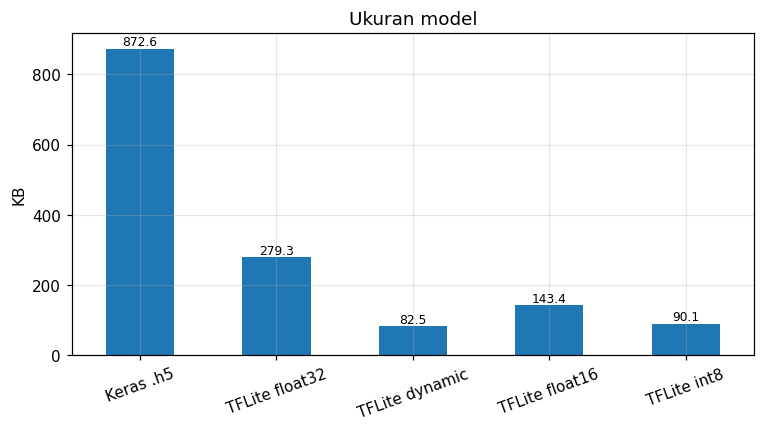

In [8]:
sizes = {'Keras .h5': os.path.getsize(join(models_path, keras_model_name + '.h5'))}
for mode in tflite_models: sizes[f'TFLite {mode}'] = os.path.getsize(join(models_path, f'{tflite_prefix}_{mode}.tflite'))
size_df = pd.DataFrame({'ukuran_KB': {k: v / 1024 for k, v in sizes.items()}})
size_df['rasio_vs_h5'] = size_df['ukuran_KB'] / size_df.loc['Keras .h5', 'ukuran_KB']
display(size_df.round(2))

ax = size_df['ukuran_KB'].plot.bar(figsize=(8, 3.8), color='tab:blue')
for p in ax.patches: ax.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom', fontsize=8)
plt.ylabel('KB'); plt.title('Ukuran model'); plt.xticks(rotation=20); plt.show()

### 9. Inferensi dengan `tf.lite.Interpreter` & perbandingan dengan Keras
Model int8 punya input/output `int8`, sehingga kita perlu **mengkuantisasi input** (`q = x/scale + zero_point`) dan **mendekuantisasi output** (`x = (q - zero_point) * scale`)
memakai parameter yang tersimpan di model.

In [9]:
def run_tflite(blob, x):
    interp = tf.lite.Interpreter(model_content=blob)
    interp.allocate_tensors()
    inp, out = interp.get_input_details()[0], interp.get_output_details()[0]
    in_scale, in_zp = inp['quantization']; out_scale, out_zp = out['quantization']
    preds = []
    for s in x:
        s_in = s[None].astype(np.float32)
        if inp['dtype'] == np.int8:
            s_in = np.clip(np.round(s_in / in_scale + in_zp), -128, 127).astype(np.int8)
        interp.set_tensor(inp['index'], s_in); interp.invoke()
        o = interp.get_tensor(out['index'])
        if out['dtype'] == np.int8:
            o = (o.astype(np.float32) - out_zp) * out_scale
        preds.append(o[0])
    return np.array(preds, dtype=np.float32)

def mse_of(pred, x): return np.mean((x - pred) ** 2, axis=(1, 2))

x_anom_eval = x_anomaly                       # 300 anomali (60 per skenario)
x_norm_eval = x_test_normal                   # 300 normal (2024-test + 2025)
y_eval = np.r_[np.zeros(len(x_norm_eval), int), np.ones(len(x_anom_eval), int)]
x_eval = np.concatenate([x_norm_eval, x_anom_eval])

results, mse_by = [], {}
# --- referensi: model Keras ---
variants = {'Keras (referensi)': lambda x: model.predict(x, verbose=0)}
for mode, blob in tflite_models.items():
    variants[f'TFLite {mode}'] = (lambda b: (lambda x: run_tflite(b, x)))(blob)

for name, fn in variants.items():
    mse_by[name] = {'eval': mse_of(fn(x_eval), x_eval), 'val': mse_of(fn(x_val_normal), x_val_normal)}
ref_dec = mse_by['Keras (referensi)']['eval'] > keras_threshold

for name, m in mse_by.items():
    thr_recal = m['val'].mean() + 3 * m['val'].std()           # threshold dihitung ulang dari val normal varian ini
    dec_k = m['eval'] > keras_threshold
    dec_r = m['eval'] > thr_recal
    results.append({
        'varian': name,
        'MSE normal (rata2)': m['eval'][y_eval == 0].mean(),
        'MSE anomali (rata2)': m['eval'][y_eval == 1].mean(),
        'AUC': roc_auc_score(y_eval, m['eval']),
        'threshold Keras': keras_threshold,
        'F1 @thr Keras': f1_score(y_eval, dec_k),
        'agreement vs Keras': (dec_k == ref_dec).mean(),
        'threshold recal.': thr_recal,
        'F1 @thr recal.': f1_score(y_eval, dec_r)})
res_df = pd.DataFrame(results).set_index('varian')
display(res_df.round(4))

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,MSE normal (rata2),MSE anomali (rata2),AUC,threshold Keras,F1 @thr Keras,agreement vs Keras,threshold recal.,F1 @thr recal.
varian,,,,,,,,
Keras (referensi),0.0222,18.656799,0.9710,0.0979,0.9198,1.0000,0.0973,0.9198
TFLite float32,0.0222,18.656799,0.9710,0.0979,0.9198,1.0000,0.0973,0.9198
TFLite dynamic,0.0226,18.681801,0.9711,0.0979,0.9198,1.0000,0.0979,0.9198
TFLite float16,0.0222,18.655800,0.9710,0.0979,0.9198,1.0000,0.0973,0.9198
TFLite int8,0.0230,19.094900,0.9706,0.0979,0.9181,0.9983,0.0983,0.9181


**Cara membaca tabel:**
- `AUC` tidak bergantung threshold → ukuran murni "seberapa baik model memisahkan normal vs anomali". AUC int8 seharusnya hanya sedikit di bawah Keras.
- `agreement vs Keras` = persentase window yang keputusan `NORMAL/ANOMALY`-nya sama dengan model Keras memakai threshold yang sama.
- Kuantisasi menambah *noise floor* kecil pada MSE. Jika `agreement`/F1 turun, gunakan **`threshold recal.`** (dihitung ulang dari validation normal untuk varian tsb.) - praktik yang disarankan sebelum deploy.

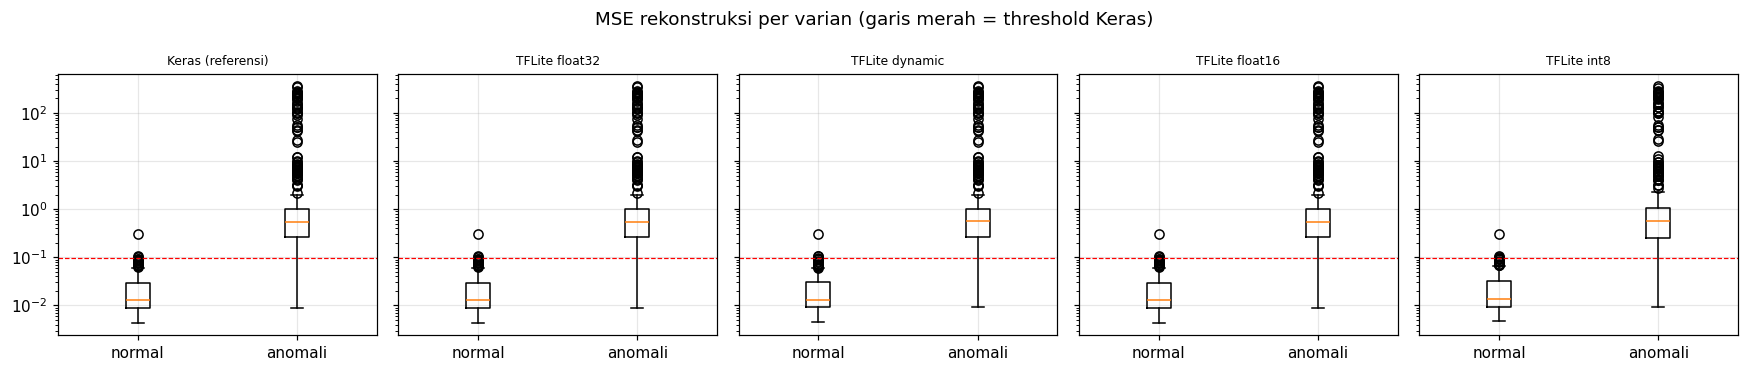

In [10]:
# Visualisasi distribusi MSE tiap varian (normal vs anomali)
names = list(mse_by)
fig, axes = plt.subplots(1, len(names), figsize=(3.2 * len(names), 3.4), sharey=True)
axes = np.atleast_1d(axes)
for ax, nm in zip(axes, names):
    m = mse_by[nm]['eval']
    ax.boxplot([m[y_eval == 0], m[y_eval == 1]]); ax.set_xticks([1, 2]); ax.set_xticklabels(['normal', 'anomali']); ax.set_yscale('log'); ax.set_title(nm, fontsize=8)
    ax.axhline(keras_threshold, color='r', ls='--', lw=.8)
plt.suptitle('MSE rekonstruksi per varian (garis merah = threshold Keras)'); plt.tight_layout(); plt.show()

### 10. Uji sampel tunggal (nilai "known-good" untuk dibandingkan dengan implementasi C++/MCU)
Analog bagian *Test Inference* pada notebook referensi: hitung MSE pada satu window normal & satu window anomali.
Sampel disimpan dalam **skala asli**, jadi pipeline yang sama dengan firmware: `scaler.transform` → model → MSE → banding threshold.

In [11]:
def score_single(raw_window, blob=None):
    x = scaler.transform(raw_window.reshape(-1, N_FEATURES)).reshape(1, window_length_hours, N_FEATURES).astype(np.float32)
    pred = model.predict(x, verbose=0) if blob is None else run_tflite(blob, x)
    per_feat = np.mean((x - pred) ** 2, axis=1)[0]
    return float(np.mean((x - pred) ** 2)), per_feat

for label, w in [('NORMAL', normal_sample_raw), ('ANOMALI', anomaly_sample_raw)]:
    mse_k, _ = score_single(w)
    line = f'{label:8s} Keras MSE={mse_k:.4f} ->' + (' ANOMALY' if mse_k > keras_threshold else ' NORMAL')
    if 'int8' in tflite_models:
        mse_q, pf = score_single(w, tflite_models['int8'])
        line += f' | int8 MSE={mse_q:.4f} -> ' + ('ANOMALY' if mse_q > keras_threshold else 'NORMAL')
    print(line)
print('Threshold (Keras):', round(keras_threshold, 4))

NORMAL   Keras MSE=0.0076 -> NORMAL | int8 MSE=0.0081 -> NORMAL
ANOMALI  Keras MSE=1.0135 -> ANOMALY | int8 MSE=0.9744 -> ANOMALY
Threshold (Keras): 0.0979


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


### 11. (Opsional) Tulis model int8 sebagai header C untuk ESP32 / Arduino
Sama seperti proyek referensi: baca byte `.tflite`, tulis sebagai `const unsigned char greenhouse_ae[]` di `greenhouse_ae.h`, lalu `#include` di firmware
(TensorFlow Lite Micro). Bagian ini boleh dilewati (`WRITE_C_HEADER = False`) bila target akhir bukan mikrokontroler fisik.

Yang perlu diketahui saat menulis firmware:
- Input model = `[1, 24, n_fitur]` **int8** (`n_fitur` = jumlah fitur di `greenhouse_config.json`, mis. 8 setelah `indoor_air_velocity` dibuang); parameter kuantisasi ditampilkan di bawah (scale & zero-point) - gunakan untuk mengkuantisasi hasil `StandardScaler` (`(x-mean)/std`) di sisi MCU.
- `scaler.mean_` dan `scaler.scale_` ditampilkan agar bisa ditanam sebagai konstanta di firmware.
- Ukuran *tensor arena* di TFLM ditentukan dengan mencoba-coba (mulai dari ±8–16 KB untuk model Dense kecil ini; naikkan bila `AllocateTensors()` gagal).
- Firmware perlu menyimpan buffer 24 jam terakhir (ring buffer) lalu menjalankan inferensi tiap jam.

In [12]:
if WRITE_C_HEADER and 'int8' in tflite_models:
    blob = tflite_models['int8']
    hex_array = [format(val, '#04x') for val in blob]
    c_model = c_writer.create_array(np.array(hex_array), 'unsigned char', c_model_name)
    c_model += f'\nconst unsigned int {c_model_name}_len = {len(blob)};\n'
    header_str = c_writer.create_header(c_model, c_model_name)
    with open(join(esp32_deploy_path, c_model_name + '.h'), 'w') as f:
        f.write(header_str)
    print(f'Header ditulis: {join(esp32_deploy_path, c_model_name)}.h  ({len(header_str)/1024:.0f} KB teks, model {len(blob)/1024:.1f} KB)')

    interp = tf.lite.Interpreter(model_content=blob); interp.allocate_tensors()
    i0, o0 = interp.get_input_details()[0], interp.get_output_details()[0]
    print('Input :', i0['shape'], i0['dtype'].__name__, 'scale/zero-point =', i0['quantization'])
    print('Output:', o0['shape'], o0['dtype'].__name__, 'scale/zero-point =', o0['quantization'])
    print('\nscaler.mean_ =', np.round(scaler.mean_, 5).tolist())
    print('scaler.scale_ =', np.round(scaler.scale_, 5).tolist())
    print('threshold     =', keras_threshold, '| threshold recal. int8 =', float(res_df.loc['TFLite int8', 'threshold recal.']))
else:
    print('Header C dilewati (WRITE_C_HEADER=False atau model int8 tidak tersedia).')

Header ditulis: /content/drive/MyDrive/greenhouse-anomaly-edgeai/models/esp32_deploy_tflite/greenhouse_ae.h  (578 KB teks, model 90.1 KB)
Input : [ 1 24  8] int8 scale/zero-point = (0.026312679052352905, -21)
Output: [ 1 24  8] int8 scale/zero-point = (0.027113813906908035, -25)

scaler.mean_ = [30.60887, 71.88629, 417.56121, 66.50162, 1.34635, 24.98661, 0.0976, 0.51066]
scaler.scale_ = [3.83684, 10.85623, 22.25117, 86.9965, 0.77865, 2.56194, 0.29678, 0.49989]
threshold     = 0.097878597676754 | threshold recal. int8 = 0.09828171133995056


---
## Ringkasan
- Model Keras (Autoencoder Dense) → `float32`, `dynamic`, `float16`, dan `int8` `.tflite` tersimpan di folder `models/`.
- Kuantisasi int8 menurunkan ukuran secara drastis (lihat tabel langkah 8) dengan penurunan AUC kecil; hitung ulang threshold per varian sebelum deploy.
- Header `greenhouse_ae.h` siap dipakai di firmware TFLite Micro (opsional).